- Nate Diaz-Santana
- Data Presentation & Visualization

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

import os
import rpy2
from rpy2 import robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


# Kia & Hyundai Theft Trend Analysis Across U.S. Cities

## Data 

### Car Thefts Map Dataset

In [6]:
carTheftsMap = pd.read_csv('carTheftsMap.csv')

In [7]:
carTheftsMap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   agency_ori               458 non-null    object 
 1   geo_name                 556 non-null    object 
 2   countCarThefts2019       556 non-null    object 
 3   countCarThefts2020       556 non-null    object 
 4   countCarThefts2021       556 non-null    object 
 5   countCarThefts2022       556 non-null    object 
 6   latitude                 556 non-null    float64
 7   longitude                556 non-null    float64
 8   percentChange2019to2022  553 non-null    float64
dtypes: float64(3), object(6)
memory usage: 39.2+ KB


In [8]:
carTheftsMap.head()

,agency_ori,geo_name,countCarThefts2019,countCarThefts2020,countCarThefts2021,countCarThefts2022,latitude,longitude,percentChange2019to2022
0,MO0490300,Carthage PD,62,58,47,26,37.175854,-94.313345,-0.580645
1,NaN,Warren County SO,112,94,76,58,41.308788,-80.847876,-0.482143
2,TX06802,Odessa PD,499,464,375,288,31.889332,-102.329889,-0.422846
3,MO0530000,Laclede County SO,55,74,54,32,37.663455,-92.549013,-0.418182
4,MO0480000,Jackson County SO,125,141,81,75,37.384401,-89.667918,-0.400000


In [9]:
carThefts = carTheftsMap.melt(
    id_vars=['agency_ori', 'geo_name', 'latitude', 'longitude', 'percentChange2019to2022'],
    value_vars=['countCarThefts2019', 'countCarThefts2020', 'countCarThefts2021', 'countCarThefts2022'],
    var_name='year',
    value_name='total_thefts'
)

In [10]:
carThefts['year'] = carThefts['year'].astype(str).str.extract(r'(\d{4})')
carThefts['year'] = carThefts['year'].astype(int)

carThefts['year'] = pd.to_datetime(carThefts['year'], format='%Y')
carThefts['year'] = carThefts['year'].dt.year

In [11]:
carThefts = carThefts.drop(columns={'agency_ori'})

In [12]:
carThefts = carThefts.dropna(subset=['percentChange2019to2022'])

In [13]:
carThefts = carThefts.rename(columns={
    'geo_name': 'city'
})

In [14]:
carThefts.head()

,city,latitude,longitude,percentChange2019to2022,year,total_thefts
0,Carthage PD,37.175854,-94.313345,-0.580645,2019,62
1,Warren County SO,41.308788,-80.847876,-0.482143,2019,112
2,Odessa PD,31.889332,-102.329889,-0.422846,2019,499
3,Laclede County SO,37.663455,-92.549013,-0.418182,2019,55
4,Jackson County SO,37.384401,-89.667918,-0.400000,2019,125


In [15]:
carThefts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2212 entries, 0 to 2223
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     2212 non-null   object 
 1   latitude                 2212 non-null   float64
 2   longitude                2212 non-null   float64
 3   percentChange2019to2022  2212 non-null   float64
 4   year                     2212 non-null   int32  
 5   total_thefts             2212 non-null   object 
dtypes: float64(3), int32(1), object(2)
memory usage: 112.3+ KB


### Kia Hyundai Milwaukee Dataset

In [17]:
milwaukee = pd.read_csv('KiaHyundaiMilwaukeeData.csv')

In [18]:
milwaukee['date'] = pd.to_datetime(
    milwaukee['month'] + ' ' + milwaukee['year'].astype(int).astype(str),
    format='%b %Y',
    errors='coerce'
)

In [19]:
milwaukee = milwaukee.rename(columns={
    'countKiaHyundaiThefts': 'kia_hyundai_thefts',
    'countOtherThefts': 'other_thefts',
    'percentKiaHyundai': 'percent_kia_hyundai'
})

milwaukee['total_thefts'] = milwaukee['percent_kia_hyundai'] + milwaukee['other_thefts']

In [20]:
milwaukee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                48 non-null     object        
 1   year                 48 non-null     int64         
 2   city                 48 non-null     object        
 3   state                48 non-null     object        
 4   kia_hyundai_thefts   48 non-null     int64         
 5   other_thefts         48 non-null     int64         
 6   percent_kia_hyundai  48 non-null     float64       
 7   date                 48 non-null     datetime64[ns]
 8   total_thefts         48 non-null     float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 3.5+ KB


In [21]:
milwaukee.head()

,month,year,city,state,kia_hyundai_thefts,other_thefts,percent_kia_hyundai,date,total_thefts
0,Jan,2019,Milwaukee,WI,22,235,0.086,2019-01-01,235.086
1,Feb,2019,Milwaukee,WI,13,218,0.056,2019-02-01,218.056
2,Mar,2019,Milwaukee,WI,10,195,0.049,2019-03-01,195.049
3,Apr,2019,Milwaukee,WI,10,238,0.040,2019-04-01,238.040
4,May,2019,Milwaukee,WI,11,280,0.038,2019-05-01,280.038


### Kia Hyundai Thefts Dataset

In [23]:
kiaHyundai = pd.read_csv('kiaHyundaiThefts.csv')

In [24]:
kiaHyundai['date'] = pd.to_datetime(
    kiaHyundai['month'] + ' ' + kiaHyundai['year'].astype(str),
    format='%b %Y',
    errors='coerce'
)

In [25]:
kiaHyundai = kiaHyundai.rename(columns={
    'countKiaHyundaiThefts': 'kia_hyundai_thefts',
    'countOtherThefts': 'other_thefts',
    'percentKiaHyundai': 'percent_kia_hyundai'
})

kiaHyundai['total_thefts'] = kiaHyundai['kia_hyundai_thefts'] + kiaHyundai['other_thefts']

In [26]:
kiaHyundai.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                552 non-null    object        
 1   year                 552 non-null    int64         
 2   city                 552 non-null    object        
 3   state                540 non-null    object        
 4   kia_hyundai_thefts   552 non-null    int64         
 5   other_thefts         552 non-null    int64         
 6   percent_kia_hyundai  552 non-null    float64       
 7   date                 552 non-null    datetime64[ns]
 8   total_thefts         552 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 38.9+ KB


In [27]:
kiaHyundai.head()

,month,year,city,state,kia_hyundai_thefts,other_thefts,percent_kia_hyundai,date,total_thefts
0,Jan,2019,Atlanta,GA,17,264,0.060,2019-01-01,281
1,Feb,2019,Atlanta,GA,11,205,0.051,2019-02-01,216
2,Mar,2019,Atlanta,GA,18,181,0.090,2019-03-01,199
3,Apr,2019,Atlanta,GA,15,223,0.063,2019-04-01,238
4,May,2019,Atlanta,GA,16,277,0.055,2019-05-01,293


### VICE Dataset

In [29]:
fix = pd.read_excel('Motherboard VICE News Kia Hyundai Theft Data.xlsx', header=[0, 1])
fix.columns = ['_'.join(map(str, col)).strip().replace('Unnamed: 0_level_0_', '').replace('Unnamed: 0_level_1', 'date') for col in fix.columns]

In [30]:
print(fix.head())

        date  Denver_Kia/Hyundais  Denver_All  Denver_Percent  \
0 2019-12-01                 48.0       615.0        0.078049   
1 2020-01-01                 21.0       519.0        0.040462   
2 2020-02-01                 28.0       402.0        0.069652   
3 2020-03-01                 35.0       508.0        0.068898   
4 2020-04-01                 39.0       616.0        0.063312   

   El Paso_Kia/Hyundais  El Paso_All  El Paso_Percent  Portland_Kia/Hyundais  \
0                    13          103         0.126214                   13.0   
1                     9           95         0.094737                   12.0   
2                     5           64         0.078125                   10.0   
3                     6           75         0.080000                    4.0   
4                     1           57         0.017544                    7.0   

   Portland_All  Portland_Percent  ...  Syracuse, NY_Percent  \
0         592.0          0.021959  ...              0.055556   


In [31]:
fixed = pd.DataFrame()
cities = set(col.split('_')[0] for col in fix.columns if col != 'date')

In [32]:
for city in cities:
    city_cols = [col for col in fix.columns if col.startswith(city)]
    subset = fix[['date'] + city_cols].copy()
    
    subset.columns = ['date'] + [col.split('_')[-1] for col in city_cols]
    
    subset['city'] = city
    fixed = pd.concat([fixed, subset], ignore_index=True)

cols = ['date', 'city'] + [c for c in fixed.columns if c not in ['date', 'city']]
fixed = fixed[cols]

In [33]:
fixed = fixed.rename(columns={
    'Kia/Hyundais': 'kia_hyundai_thefts',
    'All': 'total_thefts',
    'Percent': 'percent_kia_hyundai'
})

fixed['other_thefts'] = fixed['total_thefts'] - fixed['kia_hyundai_thefts']

In [34]:
fixed.head()

,date,city,kia_hyundai_thefts,total_thefts,percent_kia_hyundai,other_thefts
0,2019-12-01,"Houston, TX",24.0,603.0,NaN,579.0
1,2020-01-01,"Houston, TX",18.0,586.0,NaN,568.0
2,2020-02-01,"Houston, TX",15.0,556.0,NaN,541.0
3,2020-03-01,"Houston, TX",26.0,524.0,NaN,498.0
4,2020-04-01,"Houston, TX",21.0,541.0,NaN,520.0


In [35]:
fixed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 3150 non-null   datetime64[ns]
 1   city                 3150 non-null   object        
 2   kia_hyundai_thefts   2936 non-null   float64       
 3   total_thefts         2938 non-null   float64       
 4   percent_kia_hyundai  2731 non-null   float64       
 5   other_thefts         2793 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 147.8+ KB


### Merge Kia/Hyundai Datasets

In [37]:
columns = [
    'date', 'city', 'state', 'kia_hyundai_thefts',
    'other_thefts', 'total_thefts', 'percent_kia_hyundai'
]

for df in [milwaukee, kiaHyundai, fixed]:
    for col in columns:
        if col not in df.columns:
            df[col] = None
    df = df[columns]

In [38]:
data = pd.DataFrame
data = pd.concat([milwaukee[columns], kiaHyundai[columns], fixed[columns]], ignore_index=True)

In [39]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 3750 non-null   datetime64[ns]
 1   city                 3750 non-null   object        
 2   state                588 non-null    object        
 3   kia_hyundai_thefts   3536 non-null   float64       
 4   other_thefts         3393 non-null   float64       
 5   total_thefts         3538 non-null   float64       
 6   percent_kia_hyundai  3331 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 205.2+ KB


In [40]:
data.head()

,date,city,state,kia_hyundai_thefts,other_thefts,total_thefts,percent_kia_hyundai
0,2019-01-01,Milwaukee,WI,22.0,235.0,235.086,0.086
1,2019-02-01,Milwaukee,WI,13.0,218.0,218.056,0.056
2,2019-03-01,Milwaukee,WI,10.0,195.0,195.049,0.049
3,2019-04-01,Milwaukee,WI,10.0,238.0,238.040,0.040
4,2019-05-01,Milwaukee,WI,11.0,280.0,280.038,0.038


In [41]:
data = data.sort_values('date').reset_index(drop=True)

In [42]:
data['city'] = data['city'].str.strip().str.title()
data['state'] = data['state'].str.upper()
data['percent_kia_hyundai'] = pd.to_numeric(data['percent_kia_hyundai'], errors='coerce')
data['kia_hyundai_thefts'] = pd.to_numeric(data['kia_hyundai_thefts'], errors='coerce')
data['other_thefts'] = pd.to_numeric(data['other_thefts'], errors='coerce')
data['total_thefts'] = pd.to_numeric(data['total_thefts'], errors='coerce')

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 3750 non-null   datetime64[ns]
 1   city                 3750 non-null   object        
 2   state                588 non-null    object        
 3   kia_hyundai_thefts   3536 non-null   float64       
 4   other_thefts         3393 non-null   float64       
 5   total_thefts         3538 non-null   float64       
 6   percent_kia_hyundai  3331 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 205.2+ KB


In [44]:
data['state'] = data.apply(
    lambda row: row['city'].split(', ')[-1] if ', ' in row['city'] else row['state'],
    axis=1
)

In [45]:
data['city'] = data['city'].apply(lambda x: x.split(', ')[0] if ', ' in x else x)

In [46]:
data['state'] = data['state'].str.upper()

In [47]:
data.head()

,date,city,state,kia_hyundai_thefts,other_thefts,total_thefts,percent_kia_hyundai
0,2019-01-01,Milwaukee,WI,22.0,235.0,235.086,0.086
1,2019-01-01,Omaha,NE,18.0,390.0,408.000,0.044
2,2019-01-01,Atlanta,GA,17.0,264.0,281.000,0.060
3,2019-01-01,Portland,OR,9.0,525.0,534.000,0.017
4,2019-01-01,Louisville,KY,24.0,250.0,274.000,0.088


In [48]:
data.tail()

,date,city,state,kia_hyundai_thefts,other_thefts,total_thefts,percent_kia_hyundai
3745,2023-08-01,Houston,TX,363.0,NaN,NaN,NaN
3746,2023-08-01,El Paso,None,24.0,163.0,187.0,0.128342
3747,2023-08-01,Louisville,None,311.0,NaN,NaN,NaN
3748,2023-08-01,Modesto,CA,2.0,61.0,63.0,0.031746
3749,2023-08-01,Eugene,OR,2.0,56.0,58.0,0.034483


In [49]:
data['state'] = data['state'].replace({
    'D.C.': 'DC',
    'TEXAS': 'TX'
})

In [50]:
data['state'].value_counts()

state
TX    495
CA    450
NY    219
NE    138
WA    138
MD    138
WI    138
FL    135
AZ    135
OH    129
IL     93
OR     93
NV     90
VA     90
NC     90
MN     81
GA     48
KY     48
KS     45
UT     45
CT     45
RI     45
ID     45
PA     45
DC     45
Name: count, dtype: int64

In [51]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 3750 non-null   datetime64[ns]
 1   city                 3750 non-null   object        
 2   state                3063 non-null   object        
 3   kia_hyundai_thefts   3536 non-null   float64       
 4   other_thefts         3393 non-null   float64       
 5   total_thefts         3538 non-null   float64       
 6   percent_kia_hyundai  3331 non-null   float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 205.2+ KB


In [52]:
data.head()

,date,city,state,kia_hyundai_thefts,other_thefts,total_thefts,percent_kia_hyundai
0,2019-01-01,Milwaukee,WI,22.0,235.0,235.086,0.086
1,2019-01-01,Omaha,NE,18.0,390.0,408.000,0.044
2,2019-01-01,Atlanta,GA,17.0,264.0,281.000,0.060
3,2019-01-01,Portland,OR,9.0,525.0,534.000,0.017
4,2019-01-01,Louisville,KY,24.0,250.0,274.000,0.088


## Visualizations with R

In [54]:
%load_ext rpy2.ipython

In [55]:
%%R
library(ggplot2)
library(dplyr)
library(tidyr)
library(treemapify)
library(forcats)


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



In [56]:
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv['rdata'] = ro.conversion.py2rpy(data)
    ro.globalenv['rtheft'] = ro.conversion.py2rpy(carThefts)

### Pie Chart

In addition: Warning message:
In (function (expr, envir = parent.frame(), enclos = if (is.list(envir) ||  :
  NAs introduced by coercion


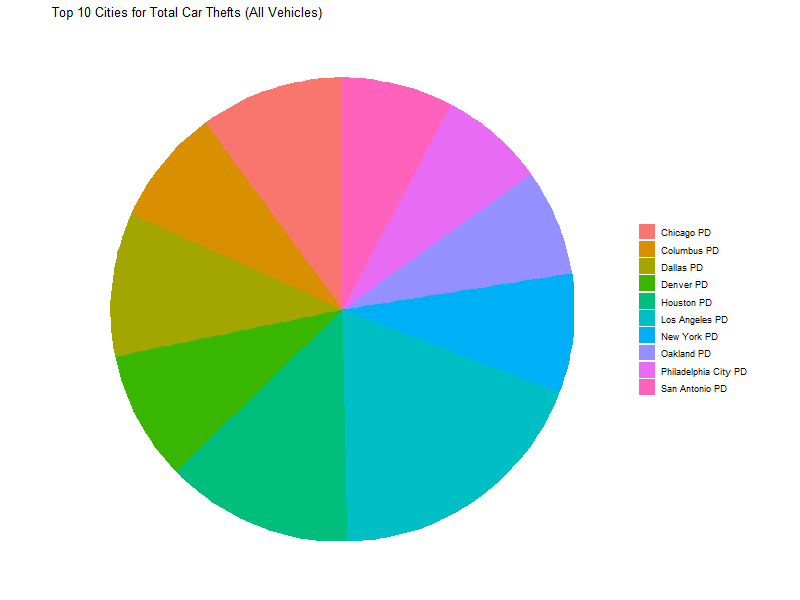

In [58]:
%%R -w 800 -h 600
rtheft$total_thefts <- as.numeric(rtheft$total_thefts)

rtheft %>%
  group_by(city) %>%
  summarize(total=sum(as.numeric(total_thefts), na.rm=TRUE)) %>%
  top_n(10, total) %>%
  ggplot(aes(x="", y=total, fill=city)) +
  geom_bar(stat="identity", width=1) +
  coord_polar("y", start=0) +
  theme_void() +
  labs(title="Top 10 Cities for Total Car Thefts (All Vehicles)") +
  theme(legend.title=element_blank())

### Donut Chart

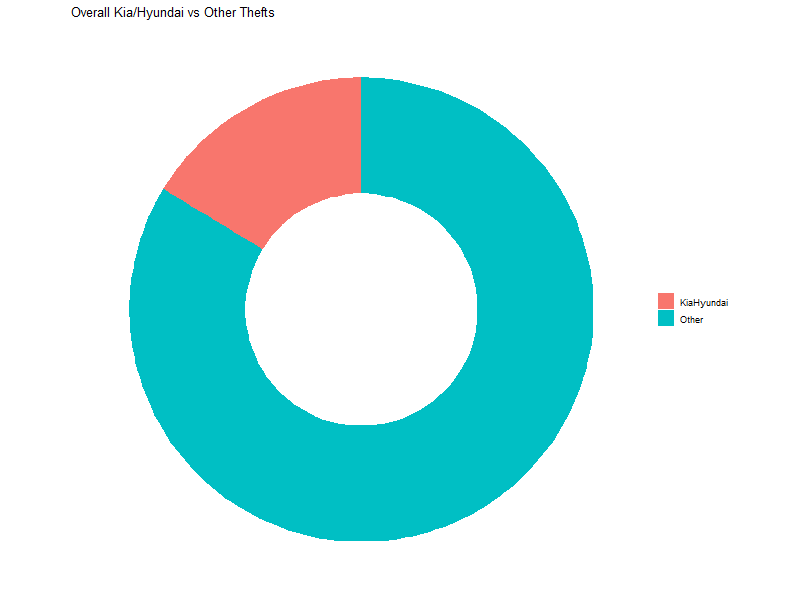

In [60]:
%%R -w 800 -h 600
kia_summary <- rdata %>%
  summarize(
    KiaHyundai = sum(kia_hyundai_thefts, na.rm=TRUE),
    Other = sum(other_thefts, na.rm=TRUE)
  ) %>%
  pivot_longer(cols=c(KiaHyundai, Other), names_to="type", values_to="count")

ggplot(kia_summary, aes(x=2, y=count, fill=type)) +
  geom_bar(stat="identity", width=1) +
  coord_polar("y", start=0) +
  xlim(0.5, 2.5) +
  theme_void() +
  labs(title="Overall Kia/Hyundai vs Other Thefts") +
  theme(legend.title=element_blank())

### Bar Graph

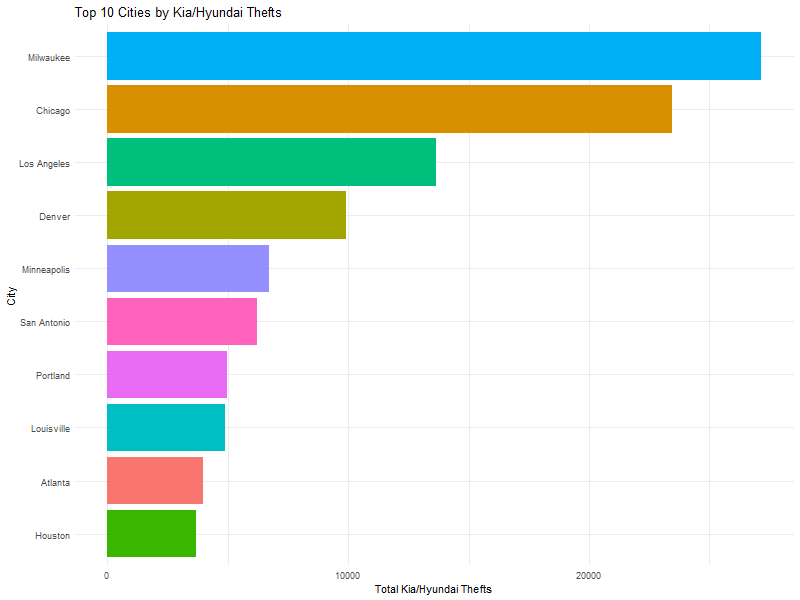

In [62]:
%%R -w 800 -h 600
top_cities <- rdata %>%
  group_by(city) %>%
  summarize(total_kia = sum(kia_hyundai_thefts, na.rm=TRUE)) %>%
  arrange(desc(total_kia)) %>%
  slice_head(n=10)

ggplot(top_cities, aes(x=reorder(city, total_kia), y=total_kia, fill=city)) +
  geom_col() +
  coord_flip() +
  labs(title="Top 10 Cities by Kia/Hyundai Thefts",
       x="City", y="Total Kia/Hyundai Thefts") +
  theme_minimal() +
  theme(legend.position="none")

### Stacked Area Chart

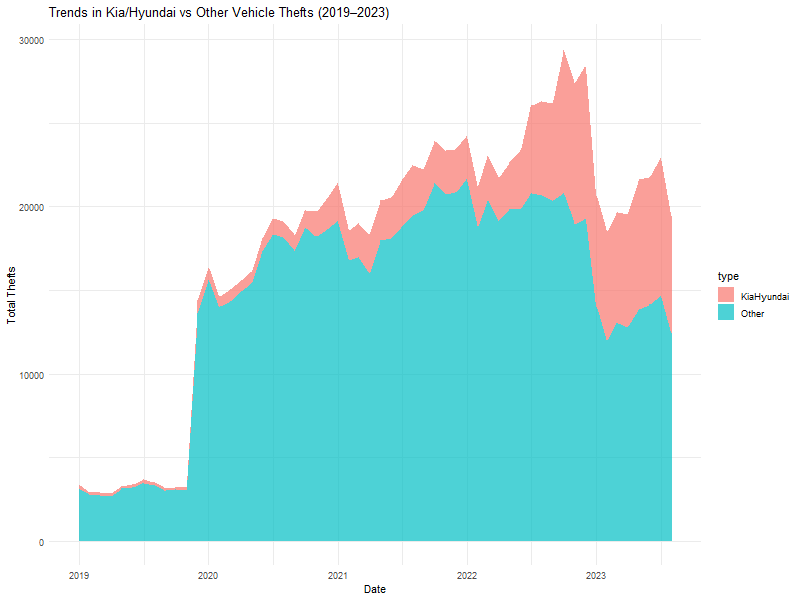

In [64]:
%%R -w 800 -h 600
rdata %>%
  group_by(date) %>%
  summarize(
    KiaHyundai = sum(kia_hyundai_thefts, na.rm=TRUE),
    Other = sum(other_thefts, na.rm=TRUE)
  ) %>%
  pivot_longer(cols=c(KiaHyundai, Other), names_to="type", values_to="count") %>%
  ggplot(aes(x=date, y=count, fill=type)) +
  geom_area(alpha=0.7) +
  labs(title="Trends in Kia/Hyundai vs Other Vehicle Thefts (2019–2023)",
       x="Date", y="Total Thefts") +
  theme_minimal()

### Tree Maps (2)

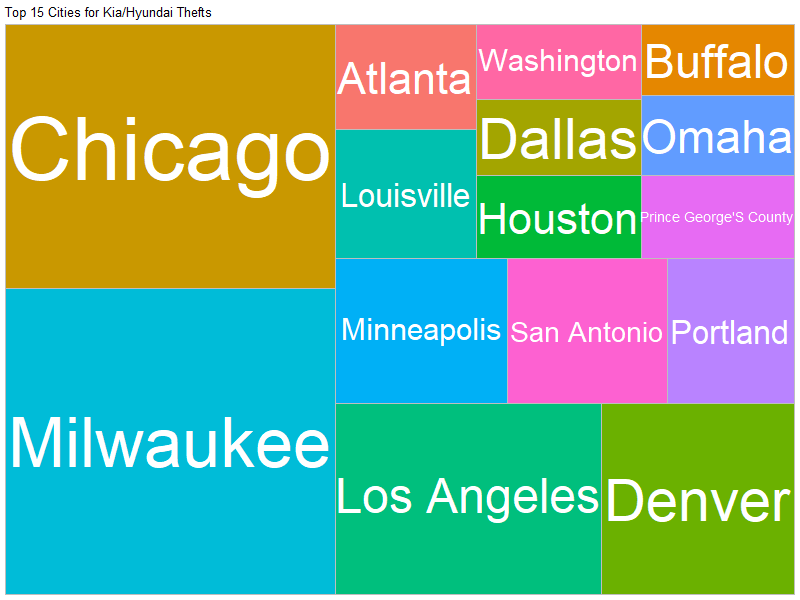

In [66]:
%%R -w 800 -h 600
rdata %>%
  group_by(city) %>%
  summarize(kia_thefts = sum(kia_hyundai_thefts, na.rm=TRUE)) %>%
  top_n(15, kia_thefts) %>%
  ggplot(aes(area=kia_thefts, fill = city, label = city)) +
  geom_treemap() +
  geom_treemap_text(colour = "white", place = "centre", grow = TRUE) +
  labs(title="Top 15 Cities for Kia/Hyundai Thefts") +
  theme(legend.position="none")

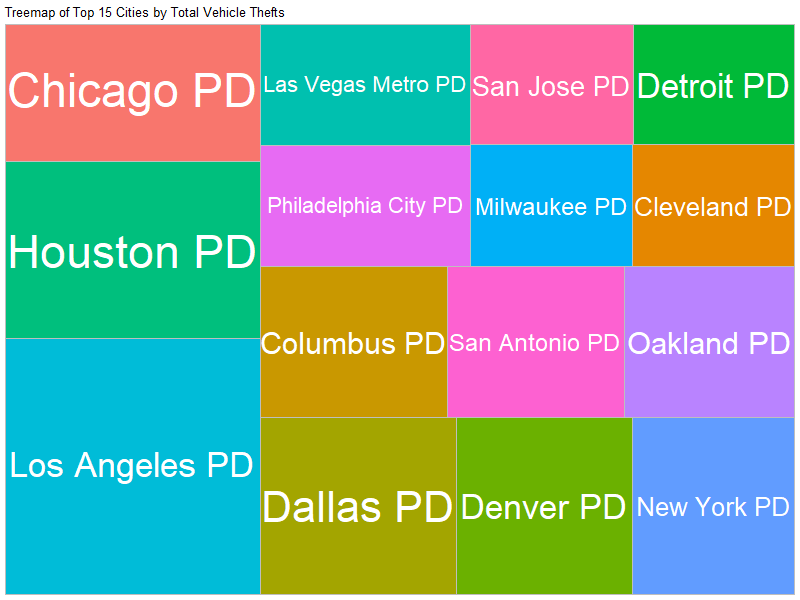

In [67]:
%%R -w 800 -h 600
rtheft$total_thefts <- as.numeric(rtheft$total_thefts)

rtheft %>%
  group_by(city) %>%
  summarize(total = sum(total_thefts, na.rm = TRUE)) %>%
  slice_max(total, n = 15) %>%
  ggplot(aes(area = total, fill = city, label = city)) +
  geom_treemap() +
  geom_treemap_text(colour = "white", place = "centre", grow = TRUE) +
  labs(title = "Treemap of Top 15 Cities by Total Vehicle Thefts") +
  theme(legend.position = "none")

## Project Overview

### Audience

The primary audiences for this project are city governments, law enforcement, and the general public. Basically, anyone interested in the Kia/Hyundai theft trends and general car thefts.

### Purpose

The primary purpose of this project is to highlight the growing trend of Kia and Hyundai vehicle thefts, likely due to an exploit making it relatively easier to hot wire/turn on without a key on certain years and models of these car brands that went viral on social media. Calling attention to this issue can help law enforcement and public safety officials prepare for this increase in car theft accordingly, along with making Kia and Hyundai owners aware of possible ways their car might get stolen and/or make them aware that their vehicles might be more targeted than others for theft.

### Medium

The medium for this project is various visualizations made in R using 4 data sets, three focused on Kia and Hyundai thefts, and one focused on overall theft trends. These charts are meant to highlight the places with the most car thefts and the increase in Kia and Hyundai thefts.

### Design

The color choice for these graphs is meant to be bright, attention-grabbing, and contrasting enough to be differentiable from the surrounding data while still visually pleasing. The text is white and in a large font to make it stand out from the background color in certain graphs, such as the treemaps, while still being easy to read. The alignment for text is centered, and all graphs are simple and clean. The sizing tends to be large, making graphs easier to see and read.

### Ethical Considerations

The main changes to the data were just typical data cleaning procedures to ensure everything worked properly when graphing and aggregating accordingly into a dataframe. The most significant change to the data was to the first dataset, where I melted it to be easier to work with and converted the yearly car theft statistics into a rate of change between the first and last year, as well as reformatting another dataset due to the way it was created and converting it to long format.

There are no legal or regulatory guidelines for the data, as it's publicly available data.

The main risk I think of is places being targeted as unsafe and dangerous due to them showing up in these visualizations, when car theft will really occur in any place. These places could easily be safe, and there could be a lot of Kia and Hyundai vehicles that boost the theft stats.


I didn't make any assumptions when cleaning or transforming the data; I tried my best to keep the data intact while still making it easier to work with. The only thing I really filtered was the agency column for one of the datasets, which was pretty much useless for this project.

Given that the datasets come from police departments or government agencies, it's safe to assume that the data is likely credible.

The data was likely sourced ethically as it's all very anonimized and seems like statistics police departments or local govermnets would disclose to the public.

There isn't much to mitigate, as there aren't really any ethical implications to worry about. At most, advising people that this isn't meant to target specific cities or demographics but rather to inform about the spike in Kia and Hyundai thefts might help mitigate my previous concern.